In [1]:
from transformers import VideoMAEFeatureExtractor, VideoMAEModel
import transformers
import decord
import torch
import numpy as np
import pandas as pd
import os
import pims
import cv2

c:\Users\Asus\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(" Transformers version:", transformers.__version__)
print(" Decord version:", decord.__version__)

 Transformers version: 4.46.3
 Decord version: 0.6.0


In [3]:
VIDEO_BASE_PATH = r"E:\nexar_dataset\train"
OUTPUT_PATH = r"E:\nexar_dataset\processed_frames"

meta_pos = pd.read_csv(r"E:\nexar_dataset\metadata1.csv")
meta_neg = pd.read_csv(r"E:\nexar_dataset\metadata2.csv")

meta_pos["target"] = 1
meta_neg["target"] = 0

train = pd.concat([meta_pos, meta_neg], ignore_index=True)

train["video_path"] = train.apply(
    lambda row: os.path.join(
        VIDEO_BASE_PATH,
        "positive" if row["target"] == 1 else "negative",
        row["file_name"]
    ),
    axis=1
)

train["id"] = range(len(train))

print(" shape:", train.shape)
print(train.head())


 shape: (1500, 10)
   file_name  time_of_event  time_of_alert light_conditions weather  \
0  00822.mp4         19.500         18.633           Normal  Cloudy   
1  00208.mp4         19.800         19.233           Normal  Cloudy   
2  00072.mp4         20.101         20.068           Normal   Clear   
3  00128.mp4         19.267         18.333           Normal   Clear   
4  00205.mp4         21.146         18.196           Normal   Clear   

       scene  time_to_accident  target  \
0      Urban               NaN       1   
1  Sub-urban               NaN       1   
2      Urban               NaN       1   
3      Urban               NaN       1   
4    Highway               NaN       1   

                                  video_path  id  
0  E:\nexar_dataset\train\positive\00822.mp4   0  
1  E:\nexar_dataset\train\positive\00208.mp4   1  
2  E:\nexar_dataset\train\positive\00072.mp4   2  
3  E:\nexar_dataset\train\positive\00128.mp4   3  
4  E:\nexar_dataset\train\positive\00205.mp4  

In [4]:
model_name = "MCG-NJU/videomae-base" 
feature_extractor = VideoMAEFeatureExtractor.from_pretrained(model_name)
model = VideoMAEModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(" Model loaded:", model_name, "| device:", device)



c:\Users\Asus\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\models\videomae\feature_extraction_videomae.py:28: FutureWarning: The class VideoMAEFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use VideoMAEImageProcessor instead.
  warnings.warn(


 Model loaded: MCG-NJU/videomae-base | device: cuda


In [5]:
def _safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default

In [6]:
def get_frame_count(sample):
    string = str(int(sample))
    while len(string) < 5:
        string = '0' + string
    video_name = string + ".mp4"

    if os.path.exists(os.path.join(VIDEO_BASE_PATH, "positive", video_name)):
        path = os.path.join(VIDEO_BASE_PATH, "positive", video_name)
    else:
        path = os.path.join(VIDEO_BASE_PATH, "negative", video_name)

    cap = cv2.VideoCapture(path)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return total_frames

def get_fps(sample):
    string = str(int(sample))
    while len(string) < 5:
        string = '0' + string
    video_name = string + ".mp4"

    if os.path.exists(os.path.join(VIDEO_BASE_PATH, "positive", video_name)):
        path = os.path.join(VIDEO_BASE_PATH, "positive", video_name)
    else:
        path = os.path.join(VIDEO_BASE_PATH, "negative", video_name)

    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

train["total_frame"] = train["id"].apply(get_frame_count)
train["fps"] = train["id"].apply(get_fps)


In [11]:
train

,file_name,time_of_event,time_of_alert,light_conditions,weather,scene,time_to_accident,target,video_path,id,total_frame,fps
0,00822.mp4,19.500,18.633,Normal,Cloudy,Urban,NaN,1,E:\nexar_dataset\train\positive\00822.mp4,0,1158.0,28.9
3,00128.mp4,19.267,18.333,Normal,Clear,Urban,NaN,1,E:\nexar_dataset\train\positive\00128.mp4,3,1203.0,30.0
4,00205.mp4,21.146,18.196,Normal,Clear,Highway,NaN,1,E:\nexar_dataset\train\positive\00205.mp4,4,1202.0,30.0
5,00408.mp4,19.953,17.551,Normal,Clear,Urban,NaN,1,E:\nexar_dataset\train\positive\00408.mp4,5,1227.0,30.6
6,00948.mp4,20.287,19.219,Normal,Clear,Sub-urban,NaN,1,E:\nexar_dataset\train\positive\00948.mp4,6,1199.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,01862.mp4,NaN,NaN,Normal,Clear,Urban,NaN,0,E:\nexar_dataset\train\negative\01862.mp4,1495,1224.0,29.9
1496,01992.mp4,NaN,NaN,Normal,Clear,Highway,NaN,0,E:\nexar_dataset\train\negative\01992.mp4,1496,1211.0,30.0
1497,01622.mp4,NaN,NaN,Normal,Cloudy,Urban,NaN,0,E:\nexar_dataset\train\negative\01622.mp4,1497,1211.0,29.9
1498,02029.mp4,NaN,NaN,Normal,Cloudy,Sub-urban,NaN,0,E:\nexar_dataset\train\negative\02029.mp4,1498,1229.0,30.5


In [12]:
def load_video_frames_train(video_path, target, fps, time_of_alert, time_of_event, end_time, num_frame=16):

    try:
        video = pims.Video(video_path)
    except Exception as e:
        print(f"Could not open {video_path}: {e}")
        return None

    if fps is None or fps == 0 or np.isnan(fps):
        print(f"Invalid FPS for {video_path}")
        return None

    if target == 0:
        mid = end_time / 2
        start_second = max(mid - 2, 0)
        end_second = min(mid + 2, end_time)
    else:
        start_second = max(0, time_of_event- 2)
        end_second = min(time_of_event + 2, end_time)

    start_frame = int(start_second * fps)
    end_frame = int(end_second * fps)
    total_frames = len(video) 

    end_frame = min(end_frame, total_frames - 1)

    if end_frame - start_frame >= num_frame:
        indices = np.linspace(start_frame, end_frame - 1, num_frame).astype(int)
    else:
        indices = list(range(start_frame, end_frame))
        while len(indices) < num_frame and end_frame > 0:
            indices.append(end_frame - 1)

    indices = [idx for idx in indices if 0 <= idx < len(video)]

    frames = []
    for idx in indices:
        try:
            frame = np.array(video[idx])
            frame = cv2.resize(frame, (224, 224))
            if frame.ndim == 2:  # grayscale
                frame = np.stack([frame] * 3, axis=-1)
            frames.append(frame.astype(np.uint8))
        except Exception as e:
            print(f"Error reading frame {idx} from {video_path}: {e}")
            continue

    if len(frames) == 0:
        print(f" No valid frames extracted from {video_path}")
        return None

    inputs = feature_extractor(frames, return_tensors="pt")
    return inputs



In [8]:
train = train.dropna(subset=['fps', 'total_frame'])
train = train[(train['fps'] > 0) & (train['total_frame'] > 0)]

print(" Valid videos for extraction:", len(train))


 Valid videos for extraction: 1056


In [13]:
import os
import torch
from tqdm import tqdm 

features = []

for i in tqdm(range(train.shape[0]), desc="Extracting video features", ncols=100):
    sample = train.iloc[i]
    video_name = sample["file_name"]

    if sample["target"] == 1:
        video_path = os.path.join(r"E:\nexar_dataset\train\positive", video_name)
    else:
        video_path = os.path.join(r"E:\nexar_dataset\train\negative", video_name)

    if not os.path.exists(video_path):
        tqdm.write(f" File not found: {video_path}")
        continue

    if sample["target"] == 1:
        inputs = load_video_frames_train(
            video_path,
            sample["target"],
            sample["fps"],
            sample["time_of_alert"],
            sample["time_of_event"],
            int(sample["total_frame"] / sample["fps"]),
            16
        )
    else:
        inputs = load_video_frames_train(
            video_path,
            sample["target"],
            sample["fps"],
            0,
            0,
            int(sample["total_frame"] / sample["fps"]),
            16
        )

    if inputs is None:
        tqdm.write(f"Skipped (no frames): {video_path}")
        continue

    with torch.no_grad():
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        video_features = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        features.append(video_features)

print("\n Feature extraction finished successfully!")
print(f"Total videos processed: {len(features)} / {train.shape[0]}")


Extracting video features: 100%|████████████████████████████████| 1056/1056 [46:32<00:00,  2.64s/it]


 Feature extraction finished successfully!
Total videos processed: 1056 / 1056


In [14]:
import tensorflow as tf
keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(768,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'] )

In [16]:
history = keras_model.fit(np.array(features).squeeze() , train['target'] , validation_split=0.2 , epochs = 10)

Epoch 1/10
27/27 [==============================] - 0s 12ms/step - loss: 0.3671 - accuracy: 0.8436 - val_loss: 0.5013 - val_accuracy: 0.7689
Epoch 2/10
27/27 [==============================] - 0s 10ms/step - loss: 0.3640 - accuracy: 0.8472 - val_loss: 0.7981 - val_accuracy: 0.6038
Epoch 3/10
27/27 [==============================] - 0s 10ms/step - loss: 0.3388 - accuracy: 0.8495 - val_loss: 0.4779 - val_accuracy: 0.7783
Epoch 4/10
27/27 [==============================] - 0s 10ms/step - loss: 0.3615 - accuracy: 0.8448 - val_loss: 0.3796 - val_accuracy: 0.8302
Epoch 5/10
27/27 [==============================] - 0s 10ms/step - loss: 0.3627 - accuracy: 0.8318 - val_loss: 0.8779 - val_accuracy: 0.5377
Epoch 6/10
27/27 [==============================] - 0s 10ms/step - loss: 0.3322 - accuracy: 0.8614 - val_loss: 0.7093 - val_accuracy: 0.6840
Epoch 7/10
27/27 [==============================] - 0s 11ms/step - loss: 0.3025 - accuracy: 0.8649 - val_loss: 0.5457 - val_accuracy: 0.7500
Epoch 8/10
27

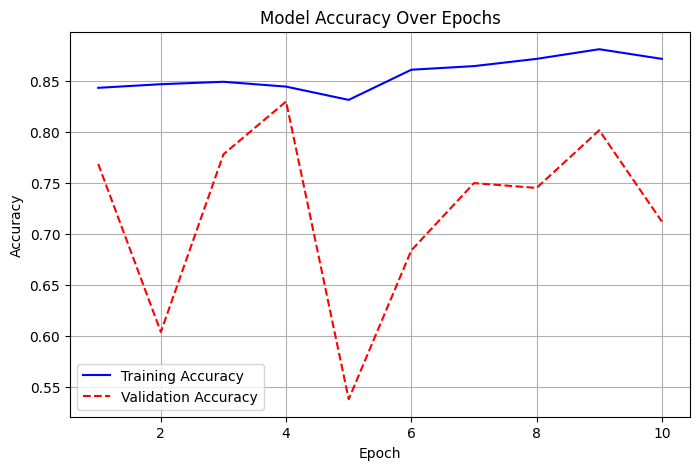

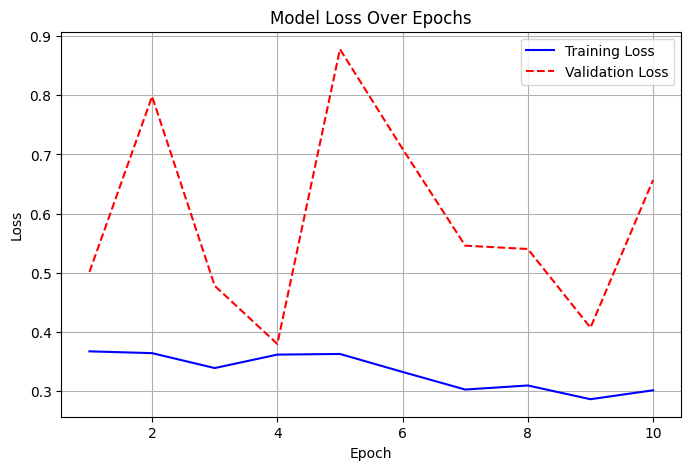

In [17]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
